In [3]:
import pandas as pd
import matplotlib.pylab as plt
import pickle

In [4]:
### load the data - in pickle format
file_ = '/Users/smarty92/Documents/postDoc_Caltech/project/draft_paper/MD/open_research_section/clust_0_short.pkl'
file_ = open(file_, 'rb')
data_ = pickle.load(file_)

In [7]:
### define the different vectors/matrices for plotting
t_obs = data_['t_obs'] ## time vector for the observations
t_pred = data_['t_pred'] ## time vector for the seismicity model
Robs = data_['Seismicity_rate_obs'] ## observations - seismcity rate
Rpred_ = data_['temporal_best_model'] ## best seismicity rate model
inter_conf = data_['95_conf-interv'] ## 95% confidence interval


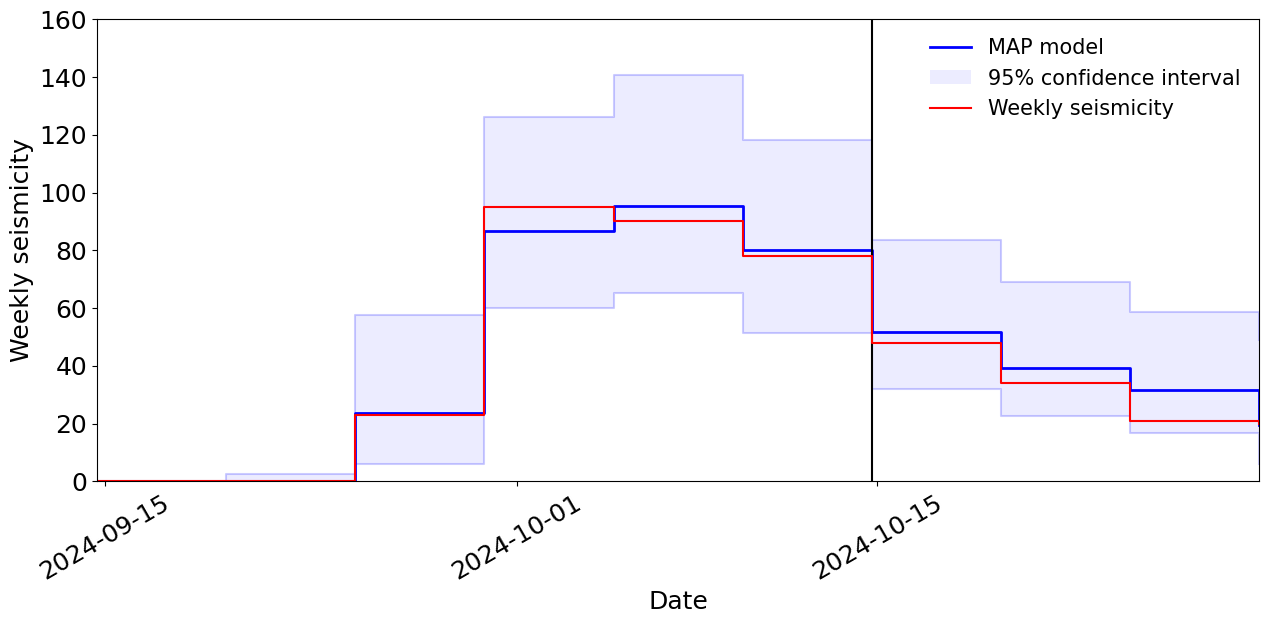

In [10]:
## plot the temporal forecast
fig,ax = plt.subplots(figsize = (15,6))
alpha = 1


ax.plot(t_pred,inter_conf[:,1],'b-',alpha = 0.2)
ax.plot(t_pred,inter_conf[:,0],'b-',alpha = 0.2)

ax.plot(t_pred,Rpred_,'b-',linewidth = 2,label = 'MAP model',alpha = alpha)

ax.fill_between(t_pred,inter_conf[:,0],Rpred_,facecolor = 'b',alpha = 0.075,label = '95% confidence interval')
ax.fill_between(t_pred,Rpred_,inter_conf[:,1],facecolor = 'b',alpha = 0.075)

t1,t2 = t_obs[0],t_obs[-1]
x_ = 160
ax.set_xlim(t1,t2 )
ax.set_ylim(0,x_)

ind  = int(len(t_pred)*0.66)

ax.vlines(t_pred[ind],0,x_,'k',linewidth = 1.5)
ax.plot(t_obs,Robs,'r-', label='Weekly seismicity',linewidth = 1.5,alpha = 1)

ax.tick_params(axis = 'both',labelsize = 18)
ax.set_xlabel('Date',fontsize = 18)
ax.set_ylabel('Weekly seismicity',fontsize = 18)
ax.legend(loc = 'upper right',fontsize = 15,facecolor='None', framealpha=1,edgecolor = 'None')
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=30)
ticks = ax.get_xticks()
ax.set_xticks(ticks[::2])



In [11]:
data_['Coulomb_Stress'].shape

(50, 50, 10)

In [1]:
### plot Coulomb Stress for the last epoch

fig,ax = plt.subplots(figsize = (6,6))
cmap = 'bwr'
levels = 3

X_,Y_ = data_['X_'],data_['Y_'] ## longitude and latitude of the grid nodes
CS = data_['Coulomb_Stress'][:,:,-1] ## coulomb stress
catalog_ = data_['catalog'] ## catalog of the cluster
vmax = CS.max()
vmin = 0


p1 = ax.pcolormesh(X_,Y_,CS,cmap = cmap,shading='gouraud',vmin = vmin , vmax = vmax)
ax.contour(X_,Y_,CS,levels = levels,colors = 'k',alpha = 0.2)
ax.scatter(catalog_['longitude'],catalog_['latitude'],marker = 'o',
           s = 20*(2**catalog_['magnitude']),
           c = 'lightgray',
          edgecolors = 'black') ### plot the earthquakes 
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
ax.set_title(str(t_obs[-1]))
cbar  = plt.colorbar(p1, orientation = 'horizontal', shrink = 0.2, aspect = 3, pad=0.1,ticks=[0, 1])
cbar.set_label('$|\DeltaCs|$',fontsize = 16)
cbar.ax.tick_params(labelsize=16)


<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
/var/folders/kj/lxqq_3f54x55m7d9pkbmm_z40000gn/T/ipykernel_45079/2414057045.py:24: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('$|\DeltaCs|$',fontsize = 16)
/var/folders/kj/lxqq_3f54x55m7d9pkbmm_z40000gn/T/ipykernel_45079/2414057045.py:24: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('$|\DeltaCs|$',fontsize = 16)


NameError: name 'plt' is not defined

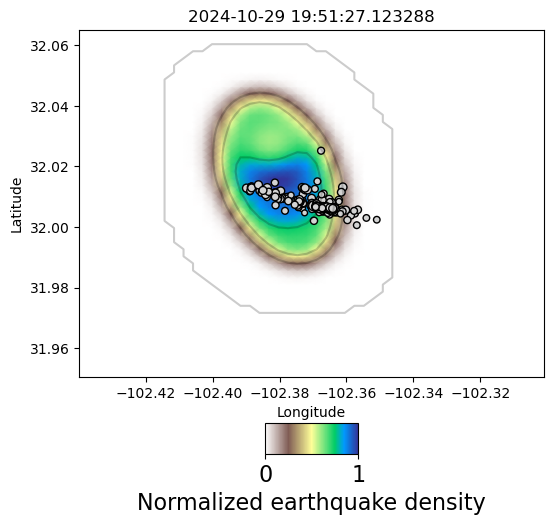

In [20]:
### plot spatial forecast for the last epoch

fig,ax = plt.subplots(figsize = (6,6))
cmap = 'terrain_r'
levels = 3

X_,Y_ = data_['X_'],data_['Y_'] ## longitude and latitude of the grid nodes
dens = data_['spatial_forecast'] ## coulomb stress
catalog_ = data_['catalog'] ## catalog of the cluster
vmax = 1
vmin = 0


p1 = ax.pcolormesh(X_,Y_,dens,cmap = cmap,shading='gouraud',vmin = vmin , vmax = vmax)
ax.contour(X_,Y_,dens,levels = levels,colors = 'k',alpha = 0.2)
ax.scatter(catalog_['longitude'],catalog_['latitude'],marker = 'o',
           s = 20*(2**catalog_['magnitude']),
           c = 'lightgray',
          edgecolors = 'black') ### plot the earthquakes 
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
ax.set_title(str(t_obs[-1]))
cbar  = plt.colorbar(p1, orientation = 'horizontal', shrink = 0.2, aspect = 3, pad=0.1,ticks=[0, 1])
cbar.set_label('Normalized earthquake density',fontsize = 16)
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([0,1])